# Streamlit Web Application for Generating Medical Images

**Goal**: To build a web applicagion that geberates images using GAN models. The app will allow users to choose a specific GAN model and specify the number of images to generate.

**Objectives**

- Build a web application using Python's Streamlit framework.
- Add custom interface features for interaction with GAN models.
- Create a .py file for the web app.

In [1]:
import torchvision
from medigan import Generators
from torchvision.transforms.functional import to_pil_image
from torchvision.utils import make_grid

**Defining Models**

In [2]:
model_ids = [
    "00001_DCGAN_MMG_CALC_ROI",
    "00002_DCGAN_MMG_MASS_ROI",
    "00003_CYCLEGAN_MMG_DENSITY_FULL",
    "00004_PIX2PIX_MMG_MASSES_W_MASKS",
    "00019_PGGAN_CHEST_XRAY",
]

In [3]:
import app

print("Models available in app:")
for model_id in app.model_ids:
    print(model_id)

Models available in app:
00001_DCGAN_MMG_CALC_ROI
00002_DCGAN_MMG_MASS_ROI
00003_CYCLEGAN_MMG_DENSITY_FULL
00004_PIX2PIX_MMG_MASSES_W_MASKS
00019_PGGAN_CHEST_XRAY


Pytorch function:

In [4]:
def torch_images(num_images, model_id):
    generators = Generators()
    dataloader = generators.get_as_torch_dataloader(
        model_id=model_id,
        install_dependencies=True,
        num_samples=num_images,
        prefetch_factor=None,
    )

    images = []
    for batch_idx, data_dict in enumerate(dataloader):
        image_list = []
        for i in data_dict:
            if "sample" in i:
                sample = data_dict.get("sample")
                if sample.dim() == 4:
                    sample = sample.squeeze(0).permute(2, 0, 1)

                sample = to_pil_image(sample).convert("RGB")
                # Convert the image to a PyTorch tensor
                transform = torchvision.transforms.Compose(
                    [
                        torchvision.transforms.ToTensor(),
                    ]
                )

                # Apply the transform to your PIL image
                sample = transform(sample)
                image_list.append(sample)

            # Preprocess the mask
            if "mask" in i:
                mask = data_dict.get("mask")
                if mask.dim() == 4:
                    mask = mask.squeeze(0).permute(2, 0, 1)
                mask = to_pil_image(mask).convert("RGB")
                mask = transform(mask)
                image_list.append(mask)

        # Organize the grid to have 'sample' images per row
        Grid = make_grid(image_list, nrow=2)

        # Change Grid tensor to be a consistent shape
        # The Grid tensor has shape [1, 128, 128, 1] in some models
        if Grid.dim() == 4:
            # Remove the singleton batch dimension
            Grid = Grid.squeeze(0)
            if Grid.size(-1) == 1:
                # Remove the singleton channel dimension (assuming grayscale)
                Grid = Grid.squeeze(-1)
            else:
                raise ValueError("Expected a single channel (grayscale) image.")

        # Convert the tensor grid to a PIL Image for display
        img = torchvision.transforms.ToPILImage()(Grid)
        images.append(img)
    return images

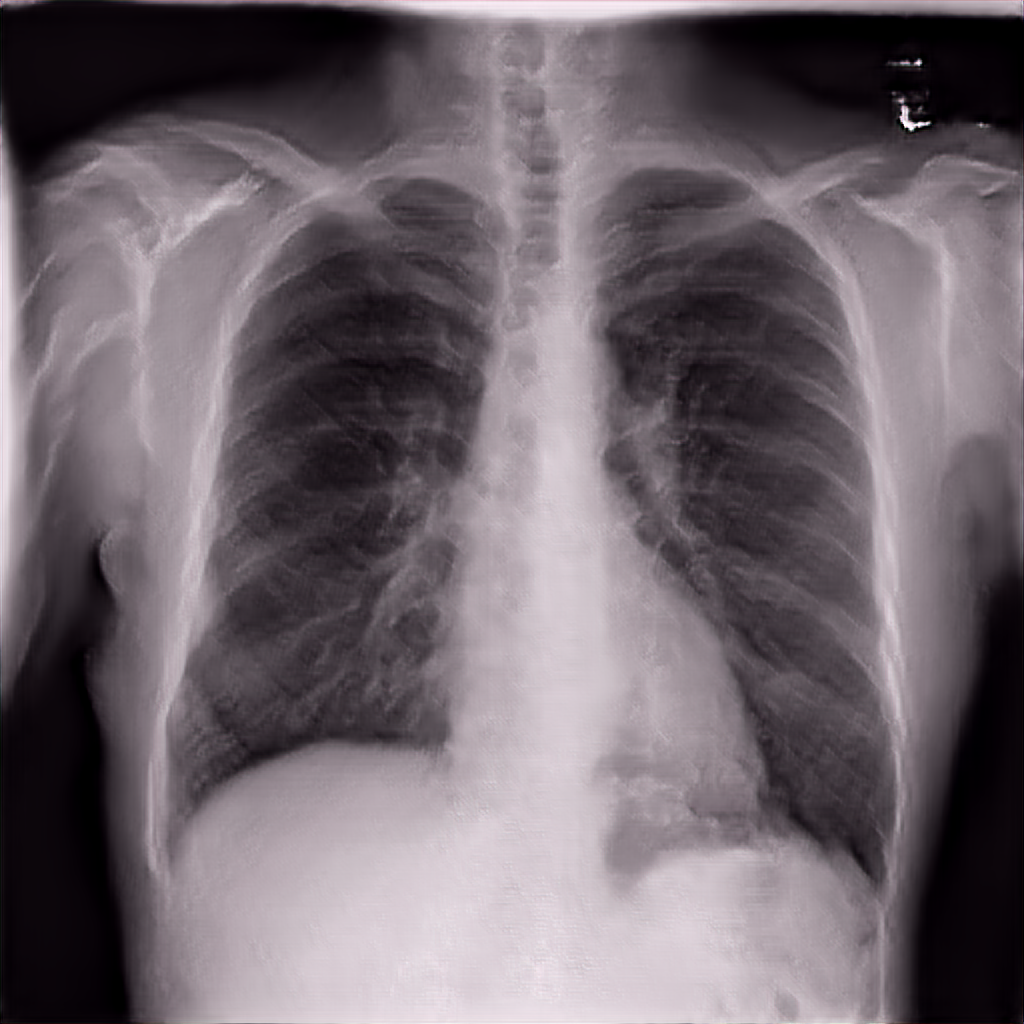

In [5]:
image = torch_images(num_images=1, model_id=model_ids[4])
image[0]

We can do this my import torch_images from app.

In [6]:
del torch_images